# Test 18: Сжатие сигналов и тензоров — за пределами изображений

**Вопрос:** Работает ли chaos SAE на данных, отличных от изображений?

**Домены:**
- A: Синусоидальные сигналы (смеси частот)
- B: Хаотические временные ряды (Lorenz attractor)
- C: Случайные тензоры (uniform, gaussian, sparse)
- D: ECG-подобные сигналы (синтетические)

**Сравнение:** Chaos a=1 + TopK vs ReLU + TopK

**Метрики:** MSE, dead neurons, устойчивость к квантованию (4 бит)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import json
from datetime import datetime

print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# === Компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


def build_signal_ae(input_dim, latent_dim=64, k_active=32, use_chaos=True):
    """1D автоэнкодер для сигналов/тензоров"""
    input_sig = keras.Input(shape=(input_dim,))
    
    if use_chaos:
        x = layers.Dense(256)(input_sig)
        x = layers.Activation(chaos_activation)(x)
        x = layers.Dense(latent_dim, name='latent_pre')(x)
        x = layers.Activation(chaos_activation)(x)
    else:
        x = layers.Dense(256, activation='relu')(input_sig)
        x = layers.Dense(latent_dim, activation='relu', name='latent_pre')(x)
    
    latent = KSparseLayer(k=k_active, name='latent_ksparse')(x)
    encoder = keras.Model(input_sig, latent, name='encoder')
    
    if use_chaos:
        x = layers.Dense(256)(latent)
        x = layers.BatchNormalization()(x)
        x = layers.Activation(chaos_activation)(x)
    else:
        x = layers.Dense(256, activation='relu')(latent)
        x = layers.BatchNormalization()(x)
    
    decoded = layers.Dense(input_dim, activation='sigmoid')(x)
    
    autoencoder = keras.Model(input_sig, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


def analyze_latent(encoder, data, threshold=1e-6):
    latents = encoder.predict(data, verbose=0)
    dead = int(np.sum(np.all(np.abs(latents) < threshold, axis=0)))
    return latents, dead


def quantize_and_reconstruct(latents, decoder, bits, k):
    if bits >= 32:
        return decoder.predict(latents, verbose=0)
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            result[i, nz] = vals
            continue
        levels = 2 ** bits - 1
        norm = (vals - vmin) / (vmax - vmin)
        q = np.round(norm * levels) / levels
        result[i, nz] = q * (vmax - vmin) + vmin
    return decoder.predict(result, verbose=0)


print("Components ready.")

Components ready.


In [3]:
# === Генераторы данных ===

def gen_sinusoidal(n_samples=5000, length=256, n_freqs=5):
    """Смеси синусоид с разными частотами и фазами"""
    data = np.zeros((n_samples, length))
    t = np.linspace(0, 2*np.pi, length)
    for i in range(n_samples):
        freqs = np.random.uniform(1, 20, n_freqs)
        amps = np.random.uniform(0.1, 1.0, n_freqs)
        phases = np.random.uniform(0, 2*np.pi, n_freqs)
        for f, a, p in zip(freqs, amps, phases):
            data[i] += a * np.sin(f * t + p)
    # Нормализация в [0, 1]
    data = (data - data.min(axis=1, keepdims=True)) / (data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)
    return data.astype('float32')


def gen_lorenz(n_samples=5000, length=256, dt=0.01):
    """Сегменты траектории аттрактора Лоренца"""
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    # Генерируем длинную траекторию
    total = n_samples * length
    x, y, z = 1.0, 1.0, 1.0
    trajectory = []
    for _ in range(total + 1000):  # warmup
        dx = sigma * (y - x) * dt
        dy = (x * (rho - z) - y) * dt
        dz = (x * y - beta * z) * dt
        x, y, z = x + dx, y + dy, z + dz
        trajectory.append(x)
    trajectory = np.array(trajectory[1000:])  # отбросить warmup
    # Нарезаем на сегменты
    data = trajectory[:n_samples * length].reshape(n_samples, length)
    # Нормализация
    data = (data - data.min(axis=1, keepdims=True)) / (data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)
    return data.astype('float32')


def gen_random_tensors(n_samples=5000, length=256, dist='mixed'):
    """Случайные тензоры: uniform, gaussian, sparse"""
    data = []
    for i in range(n_samples):
        choice = i % 3 if dist == 'mixed' else {'uniform': 0, 'gaussian': 1, 'sparse': 2}[dist]
        if choice == 0:
            vec = np.random.uniform(0, 1, length)
        elif choice == 1:
            vec = np.random.randn(length)
            vec = (vec - vec.min()) / (vec.max() - vec.min() + 1e-8)
        else:
            vec = np.zeros(length)
            nnz = np.random.randint(10, length // 4)
            idx = np.random.choice(length, nnz, replace=False)
            vec[idx] = np.random.uniform(0, 1, nnz)
        data.append(vec)
    return np.array(data).astype('float32')


def gen_ecg_like(n_samples=5000, length=256):
    """Синтетические ECG-подобные сигналы"""
    data = np.zeros((n_samples, length))
    t = np.linspace(0, 4*np.pi, length)
    for i in range(n_samples):
        hr = np.random.uniform(0.8, 1.5)  # heart rate variation
        noise_level = np.random.uniform(0.01, 0.05)
        # P wave
        sig = 0.2 * np.exp(-((t * hr - 1.0) ** 2) / 0.02)
        # QRS complex
        sig += -0.3 * np.exp(-((t * hr - 1.8) ** 2) / 0.005)
        sig += 1.0 * np.exp(-((t * hr - 2.0) ** 2) / 0.003)
        sig += -0.2 * np.exp(-((t * hr - 2.2) ** 2) / 0.005)
        # T wave
        sig += 0.3 * np.exp(-((t * hr - 3.0) ** 2) / 0.03)
        # Второй удар
        sig += 0.2 * np.exp(-((t * hr - 7.0) ** 2) / 0.02)
        sig += 1.0 * np.exp(-((t * hr - 8.0) ** 2) / 0.003)
        sig += 0.3 * np.exp(-((t * hr - 9.0) ** 2) / 0.03)
        # Noise
        sig += noise_level * np.random.randn(length)
        data[i] = sig
    # Нормализация
    data = (data - data.min(axis=1, keepdims=True)) / (data.max(axis=1, keepdims=True) - data.min(axis=1, keepdims=True) + 1e-8)
    return data.astype('float32')


print("Data generators ready.")

Data generators ready.


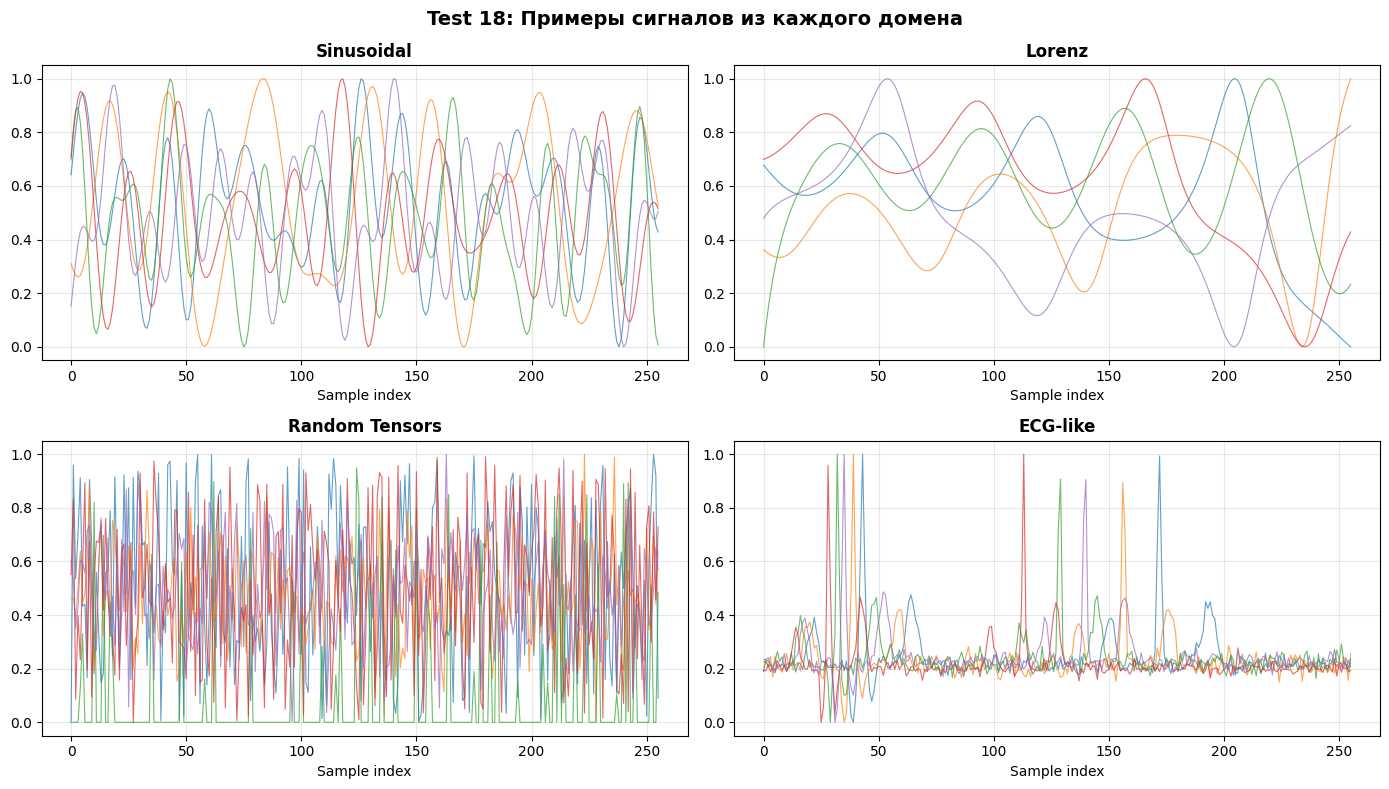

Sinusoidal: shape=(5000, 256), range=[0.000, 1.000]
Lorenz: shape=(5000, 256), range=[0.000, 1.000]
Random Tensors: shape=(5000, 256), range=[0.000, 1.000]
ECG-like: shape=(5000, 256), range=[0.000, 1.000]


In [4]:
# === Генерация данных ===
np.random.seed(42)

datasets = {
    'Sinusoidal': gen_sinusoidal(5000, 256),
    'Lorenz': gen_lorenz(5000, 256),
    'Random Tensors': gen_random_tensors(5000, 256),
    'ECG-like': gen_ecg_like(5000, 256),
}

# Визуализация примеров
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, data) in zip(axes.flat, datasets.items()):
    for i in range(5):
        ax.plot(data[i], alpha=0.7, linewidth=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Sample index')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Test 18: Примеры сигналов из каждого домена', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for name, data in datasets.items():
    print(f"{name}: shape={data.shape}, range=[{data.min():.3f}, {data.max():.3f}]")

In [5]:
# === Эксперимент ===
NUM_RUNS = 5
EPOCHS = 20
BATCH_SIZE = 128
LATENT_DIM = 64
K_ACTIVE = 32
INPUT_DIM = 256

results = {}

for domain_name, data in datasets.items():
    print(f"\n{'='*70}")
    print(f"  Домен: {domain_name}")
    print(f"{'='*70}")
    
    # Train/test split
    split = int(len(data) * 0.8)
    x_train_d, x_test_d = data[:split], data[split:]
    
    domain_results = {}
    
    for method_name, use_chaos in [('Chaos_a1', True), ('TopK_ReLU', False)]:
        runs = []
        for run in range(NUM_RUNS):
            np.random.seed(run)
            tf.random.set_seed(run)
            
            ae, enc = build_signal_ae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=use_chaos)
            ae.fit(x_train_d, x_train_d, epochs=EPOCHS, batch_size=BATCH_SIZE,
                   validation_data=(x_test_d, x_test_d), verbose=0)
            
            latents, dead = analyze_latent(enc, x_test_d)
            base_loss = float(ae.evaluate(x_test_d, x_test_d, verbose=0))
            
            # Декодер
            decoder_input = keras.Input(shape=(LATENT_DIM,))
            x = decoder_input
            found = False
            for layer in ae.layers:
                if layer.name == 'latent_ksparse':
                    found = True
                    continue
                if found:
                    x = layer(x)
            decoder = keras.Model(decoder_input, x)
            
            # Квантование 4 бит
            q_recon = quantize_and_reconstruct(latents, decoder, bits=4, k=K_ACTIVE)
            q_loss = float(np.mean((x_test_d - q_recon) ** 2))
            
            runs.append({
                'base_loss': base_loss,
                'quant4_loss': q_loss,
                'dead': dead,
            })
            
            del ae, enc, decoder
            keras.backend.clear_session()
        
        domain_results[method_name] = runs
        
        bl = [r['base_loss'] for r in runs]
        ql = [r['quant4_loss'] for r in runs]
        dl = [r['dead'] for r in runs]
        print(f"  {method_name:12s}: loss={np.mean(bl):.4f}±{np.std(bl):.4f}, "
              f"4bit={np.mean(ql):.4f}±{np.std(ql):.4f}, "
              f"dead={np.mean(dl):.1f}")
    
    results[domain_name] = domain_results

print("\nAll experiments done.")


  Домен: Sinusoidal


2026-04-06 19:19:36.335331: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 19:19:36.335357: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 19:19:36.335360: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 19:19:36.335375: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 19:19:36.335384: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-06 19:19:36.707976: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  Chaos_a1    : loss=0.0120±0.0022, 4bit=0.0121±0.0022, dead=0.6
  TopK_ReLU   : loss=0.0335±0.0052, 4bit=0.0410±0.0057, dead=8.8

  Домен: Lorenz
  Chaos_a1    : loss=0.0032±0.0005, 4bit=0.0033±0.0005, dead=0.2
  TopK_ReLU   : loss=0.0086±0.0012, 4bit=0.0095±0.0012, dead=2.0

  Домен: Random Tensors
  Chaos_a1    : loss=0.0498±0.0013, 4bit=0.0499±0.0013, dead=0.0
  TopK_ReLU   : loss=0.0595±0.0072, 4bit=0.0605±0.0069, dead=2.8

  Домен: ECG-like
  Chaos_a1    : loss=0.0016±0.0001, 4bit=0.0017±0.0001, dead=0.0
  TopK_ReLU   : loss=0.0066±0.0035, 4bit=0.0075±0.0039, dead=7.4

All experiments done.


In [6]:
# === Сводная таблица ===
print("\n" + "=" * 85)
print("СВОДНАЯ ТАБЛИЦА: Все домены")
print("=" * 85)
print(f"{'Домен':<18} {'Метод':<12} {'Base Loss':>12} {'4-bit Loss':>12} {'Dead':>8} {'Деград.':>8}")
print('-' * 85)

summary = {}

for domain_name in datasets:
    summary[domain_name] = {}
    for method_name in ['Chaos_a1', 'TopK_ReLU']:
        runs = results[domain_name][method_name]
        bl = np.mean([r['base_loss'] for r in runs])
        ql = np.mean([r['quant4_loss'] for r in runs])
        dl = np.mean([r['dead'] for r in runs])
        degrad = (ql - bl) / bl * 100 if bl > 0 else 0
        
        summary[domain_name][method_name] = {
            'base_loss': bl, 'quant_loss': ql, 'dead': dl, 'degradation': degrad
        }
        
        print(f"{domain_name:<18} {method_name:<12} {bl:>11.4f} {ql:>11.4f} {dl:>7.1f} {degrad:>+7.1f}%")
    print()


СВОДНАЯ ТАБЛИЦА: Все домены
Домен              Метод           Base Loss   4-bit Loss     Dead  Деград.
-------------------------------------------------------------------------------------
Sinusoidal         Chaos_a1          0.0120      0.0121     0.6    +0.9%
Sinusoidal         TopK_ReLU         0.0335      0.0410     8.8   +22.4%

Lorenz             Chaos_a1          0.0032      0.0033     0.2    +1.5%
Lorenz             TopK_ReLU         0.0086      0.0095     2.0    +9.8%

Random Tensors     Chaos_a1          0.0498      0.0499     0.0    +0.1%
Random Tensors     TopK_ReLU         0.0595      0.0605     2.8    +1.6%

ECG-like           Chaos_a1          0.0016      0.0017     0.0    +2.7%
ECG-like           TopK_ReLU         0.0066      0.0075     7.4   +14.1%



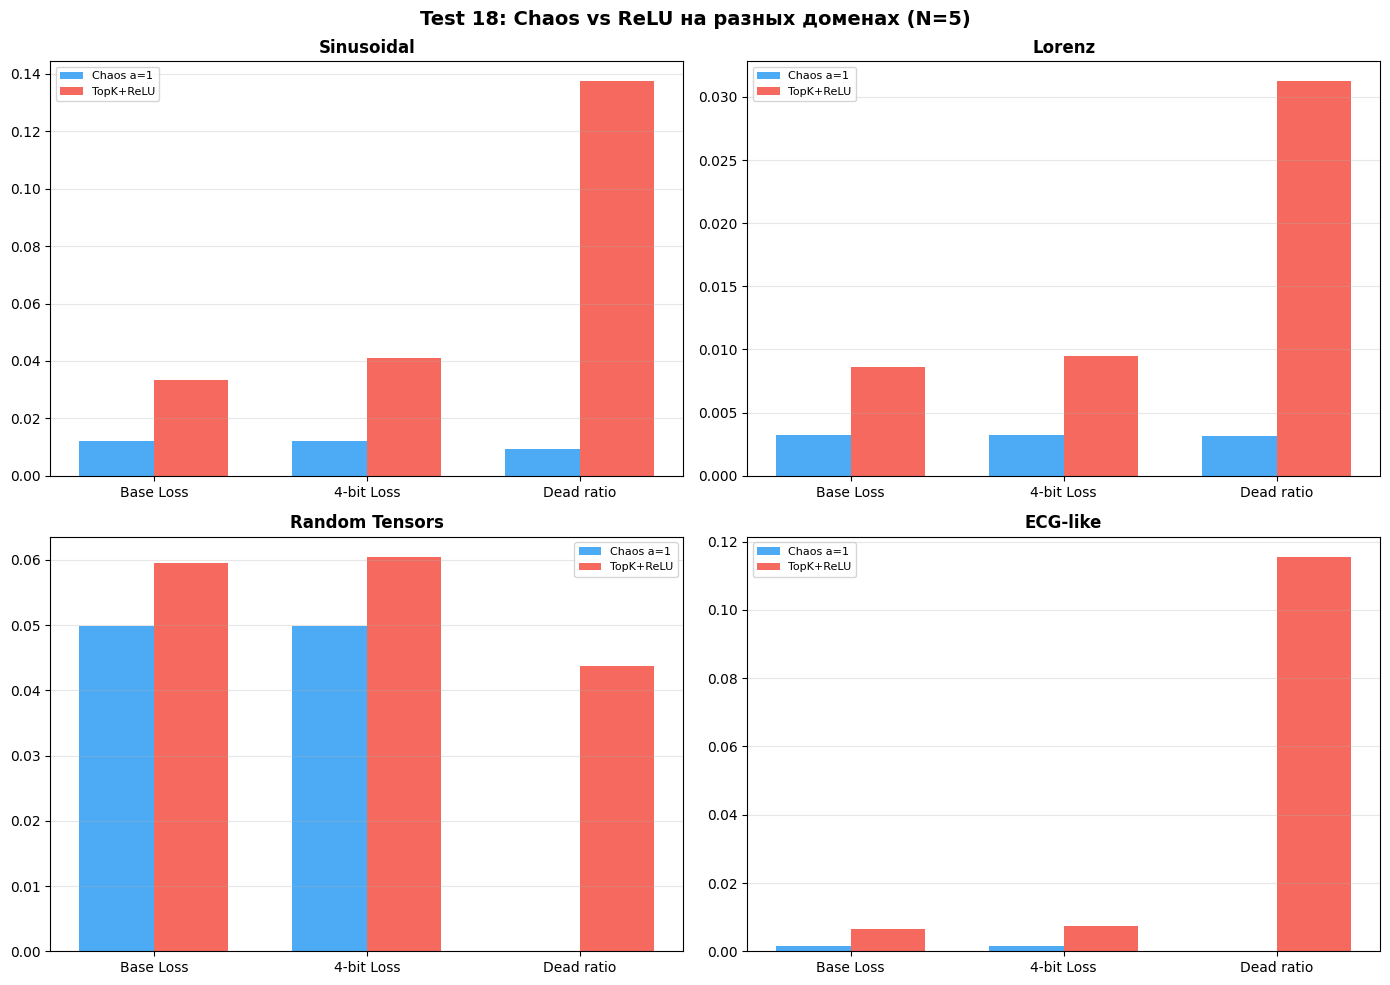

In [7]:
# === Визуализация: Chaos vs ReLU по доменам ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, domain_name in zip(axes.flat, datasets.keys()):
    chaos = summary[domain_name]['Chaos_a1']
    relu = summary[domain_name]['TopK_ReLU']
    
    x_pos = np.arange(3)
    width = 0.35
    
    chaos_vals = [chaos['base_loss'], chaos['quant_loss'], chaos['dead'] / LATENT_DIM]
    relu_vals = [relu['base_loss'], relu['quant_loss'], relu['dead'] / LATENT_DIM]
    
    bars1 = ax.bar(x_pos - width/2, chaos_vals, width, color='#2196F3', alpha=0.8, label='Chaos a=1')
    bars2 = ax.bar(x_pos + width/2, relu_vals, width, color='#F44336', alpha=0.8, label='TopK+ReLU')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Base Loss', '4-bit Loss', 'Dead ratio'])
    ax.set_title(domain_name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Test 18: Chaos vs ReLU на разных доменах (N={NUM_RUNS})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Обучение моделей для визуализации...


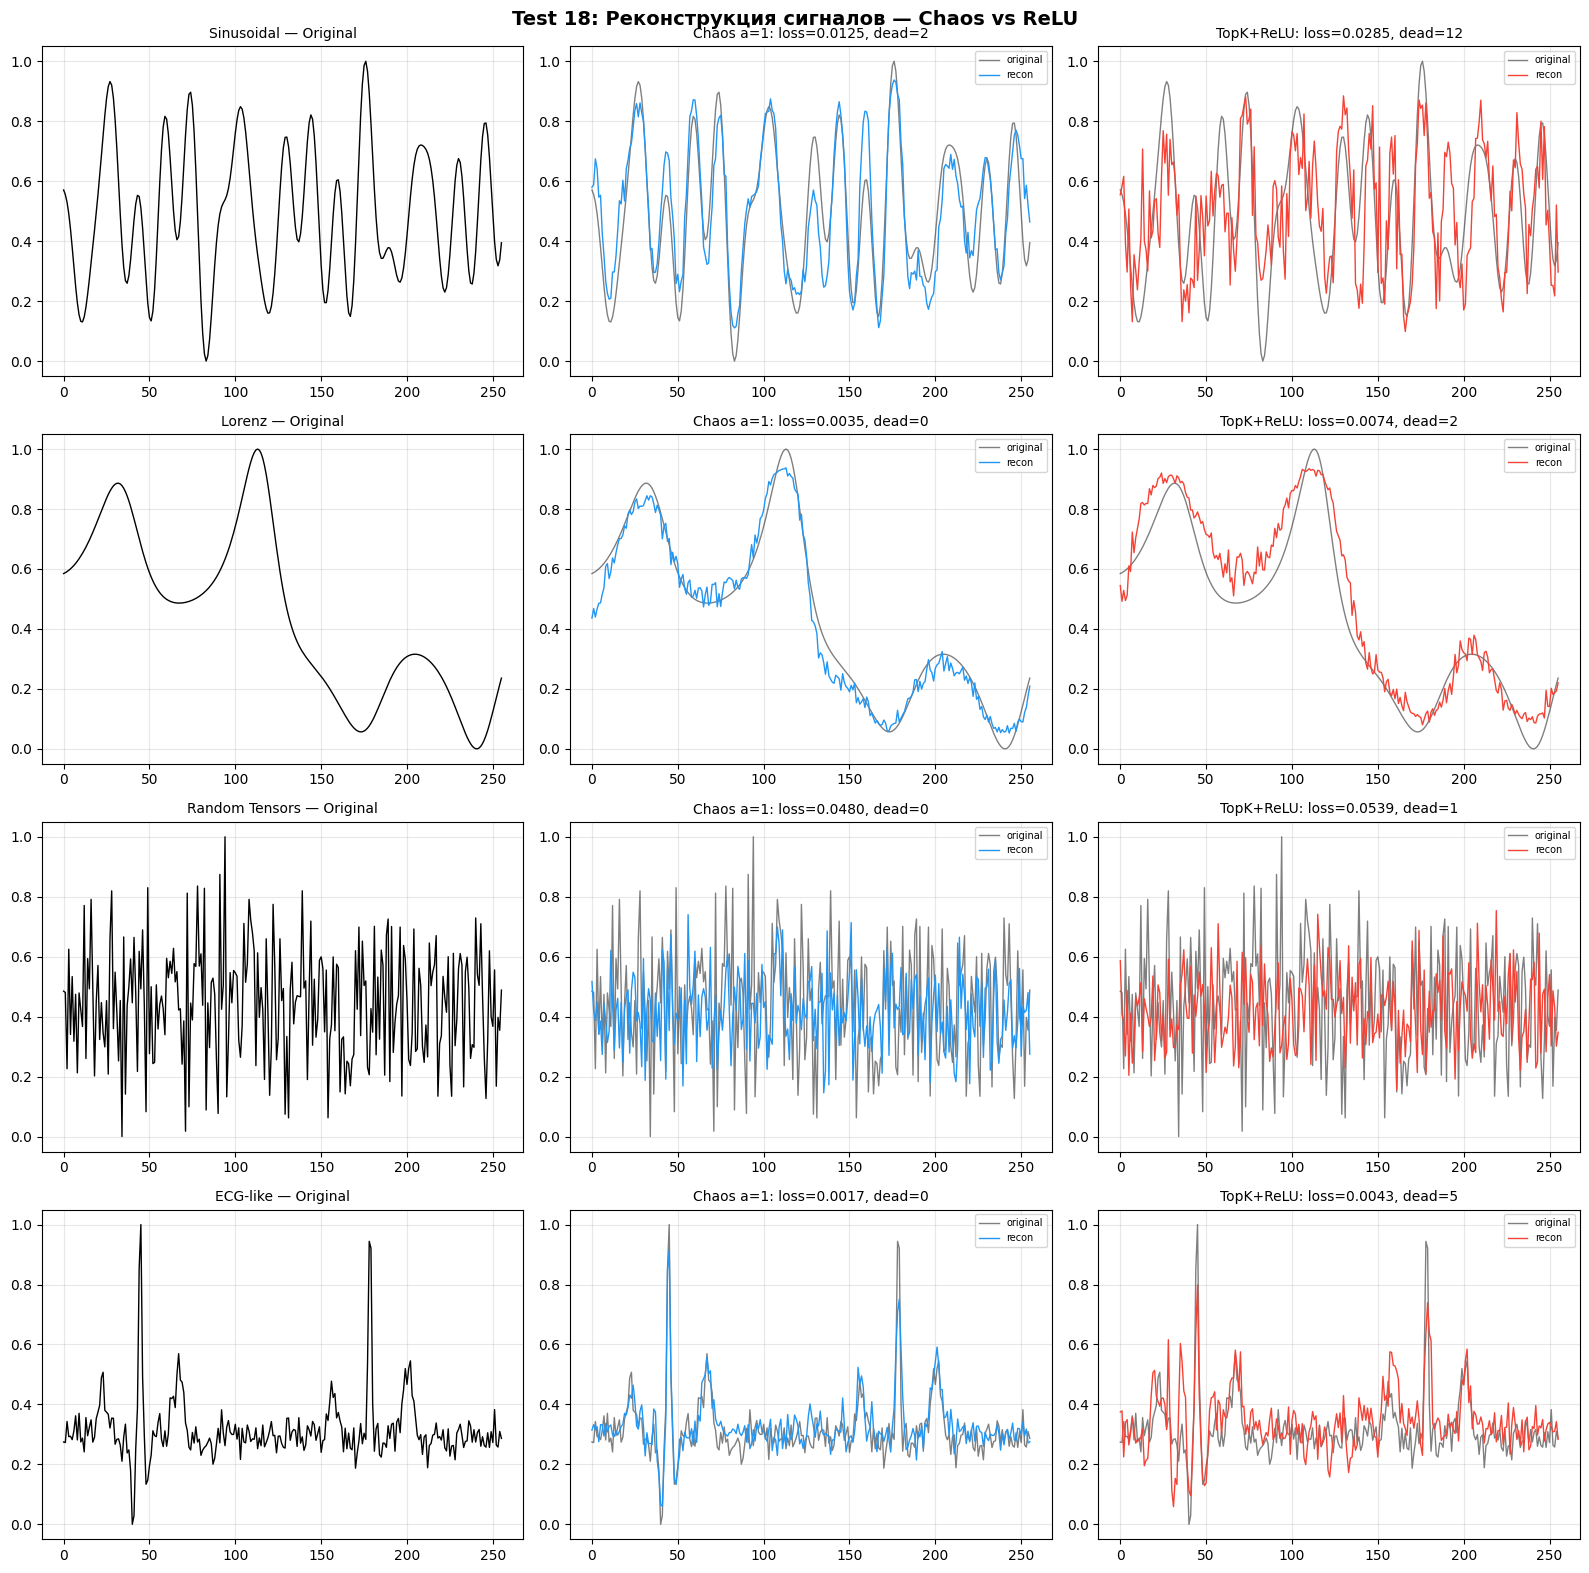

Done.


In [8]:
# === Визуализация реконструкций ===
print("Обучение моделей для визуализации...")

fig, axes = plt.subplots(len(datasets), 3, figsize=(16, 4 * len(datasets)))

for row, (domain_name, data) in enumerate(datasets.items()):
    split = int(len(data) * 0.8)
    x_test_d = data[split:]
    sample = x_test_d[:1]
    
    for col, (method_name, use_chaos) in enumerate([
        ('Original', None),
        ('Chaos a=1', True),
        ('TopK+ReLU', False)
    ]):
        if use_chaos is None:
            axes[row, col].plot(sample[0], color='black', linewidth=1)
            axes[row, col].set_title(f'{domain_name} — Original', fontsize=10)
        else:
            np.random.seed(0)
            tf.random.set_seed(0)
            ae, enc = build_signal_ae(INPUT_DIM, LATENT_DIM, K_ACTIVE, use_chaos=use_chaos)
            ae.fit(data[:split], data[:split], epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            recon = ae.predict(sample, verbose=0)
            latents, dead = analyze_latent(enc, x_test_d)
            loss = float(np.mean((x_test_d - ae.predict(x_test_d, verbose=0)) ** 2))
            
            axes[row, col].plot(sample[0], color='black', linewidth=1, alpha=0.5, label='original')
            axes[row, col].plot(recon[0], color='#2196F3' if use_chaos else '#F44336', linewidth=1, label='recon')
            axes[row, col].set_title(f'{method_name}: loss={loss:.4f}, dead={dead}', fontsize=10)
            axes[row, col].legend(fontsize=7)
            
            del ae, enc
            keras.backend.clear_session()
        
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].set_ylim(-0.05, 1.05)

plt.suptitle('Test 18: Реконструкция сигналов — Chaos vs ReLU',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Done.")

In [9]:
# === Сохранение ===
save_data = {
    'experiment': 'signal_tensor_compression',
    'timestamp': datetime.now().isoformat(),
    'config': {
        'domains': list(datasets.keys()),
        'num_runs': NUM_RUNS,
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'latent_dim': LATENT_DIM,
        'k_active': K_ACTIVE,
        'input_dim': INPUT_DIM,
    },
    'results': results,
    'summary': summary,
}

json_path = f'../jsons/signal_tensor_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(json_path, 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print(f"Results saved: {json_path}")

Results saved: ../jsons/signal_tensor_20260406_192834.json
